In [1]:
import pandas as pd
import numpy as np
import shap
import joblib
pd.set_option("display.max_columns",None)


C:\Users\prajin\PycharmProjects\Explainable-Sepsis-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = joblib.load("../models/physionet_lightgbm.pkl")### joblib python library is used for saving and loading trained model
print("model type", type(model))


model type <class 'lightgbm.sklearn.LGBMClassifier'>


In [3]:
print("number of features",model.n_features_in_)
print("\nfirst 10 features" )
print(model.feature_name_[:10])
print("\nnumber of classes",len(model.classes_))
print("model classes",model.classes_)

number of features 200

first 10 features
['HR_mean', 'HR_min', 'HR_max', 'HR_std', 'HR_last', 'O2Sat_mean', 'O2Sat_min', 'O2Sat_max', 'O2Sat_std', 'O2Sat_last']

number of classes 2
model classes [0 1]


In [4]:
feature_dataset = pd.read_csv("../data/processed/feature_dataset.csv")
X = feature_dataset.drop(columns=["SepsisLabel"])
y = feature_dataset["SepsisLabel"]
print("DATASET SHAPE:", feature_dataset.shape)
print("FEATURE MATRIX SHAPE:", X.shape)
print("TARGET SHAPE:", y.shape)

DATASET SHAPE: (20336, 201)
FEATURE MATRIX SHAPE: (20336, 200)
TARGET SHAPE: (20336,)


In [5]:
print("Model features :", model.n_features_in_)
print("Dataset features:", X.shape[1])

print("\nFeatures match:",
      model.n_features_in_ == X.shape[1])

Model features : 200
Dataset features: 200

Features match: True


In [6]:
### creating shap
explainer = shap.TreeExplainer(model)
### data selection for shap
X_shap = X.sample(
    n=min(2000, len(X)),
    random_state = 42
)
print(" shap dataset:", X_shap.shape)
### output 2000 denotes the patient and  the 200  is the feature's used

 shap dataset: (2000, 200)


In [8]:
### calculating shap values
shap_values = explainer.shap_values(X_shap)
print(" shap values calculated")
print("shap value shape:", np.array(shap_values).shape)

 shap values calculated
shap value shape: (2000, 200)


C:\Users\prajin\PycharmProjects\Explainable-Sepsis-AI\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [9]:
mean_abs_shap = np.abs(shap_values).mean()  ### finding mean absolute of shap values
feature_importance = pd.DataFrame({    ### creating a dataframe using features and mean                                                         absolute
    "features": X_shap.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values(
    "mean_abs_shap",
    ascending = False
)
print("important feature", feature_importance.head(10))

important feature      features  mean_abs_shap
0     HR_mean       0.030527
1      HR_min       0.030527
2      HR_max       0.030527
3      HR_std       0.030527
4     HR_last       0.030527
5  O2Sat_mean       0.030527
6   O2Sat_min       0.030527
7   O2Sat_max       0.030527
8   O2Sat_std       0.030527
9  O2Sat_last       0.030527


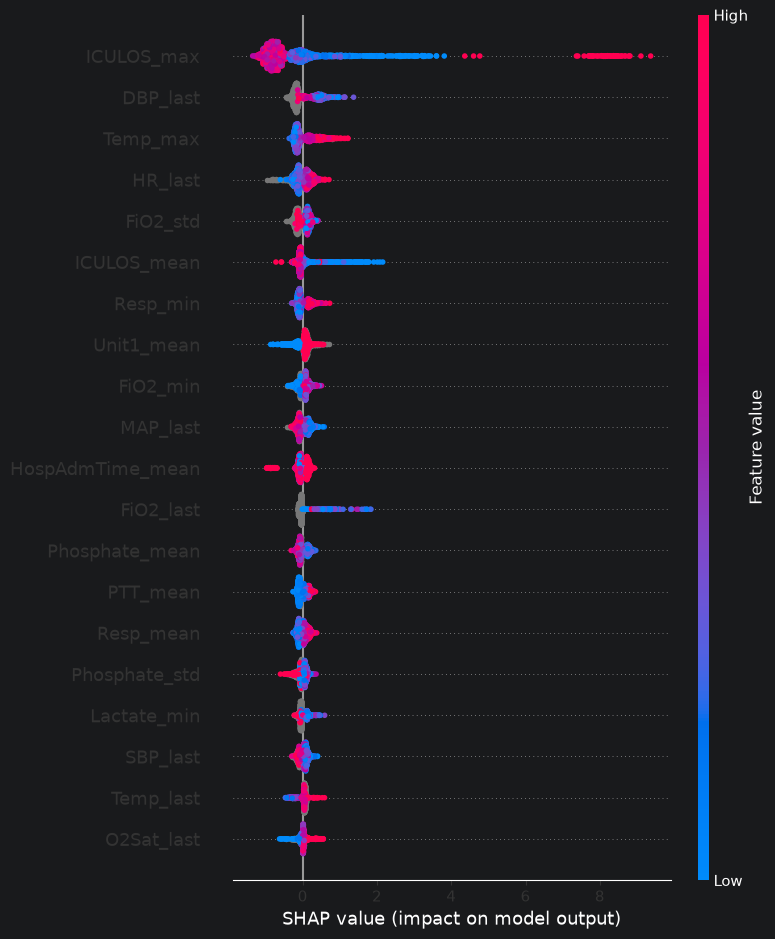

In [10]:
### besswarm plot / swarm plotting the features
shap.summary_plot(
    shap_values,
    X_shap
)
### output :
### this plot represents what are the factor influence the model for the prediction

### local shap explanation

In [11]:
sample_index = 0 ### selecting a sample for local shap
X_local = X.iloc[[sample_index]] ### iloc = integer location -- identifying the location of the sample_index
print("selected sample shape", X_local.shape)
print("\nmodel prediction", model.predict(X_local))
print("\nprediction probability", model.predict_proba(X_local))
### output:
## model's prediction [] and the probability of class 0 and class 1

selected sample shape (1, 200)

model prediction [0]

prediction probability [[0.99388885 0.00611115]]


In [13]:
shap_local = explainer.shap_values(X_local)
print("local shap value calculated")
print(" local shap shape:",np.array (shap_local).shape)

local shap value calculated
 local shap shape: (1, 200)


C:\Users\prajin\PycharmProjects\Explainable-Sepsis-AI\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [14]:
### safety check
if isinstance(shap_local, list):
    shap_local_values = shap_local[0]
else:
    shap_local_values = shap_local
    print("SHAP values shape:", shap_local_values.shape)

SHAP values shape: (1, 200)


### Shap explanation for particular patient

In [17]:
shap_explanation = shap.Explanation(
    values=shap_local_values[0],
    base_values=explainer.expected_value,
    data=X_local.iloc[0].values,
    feature_names=X_local.columns
)
print("shap explanation added")

shap explanation added


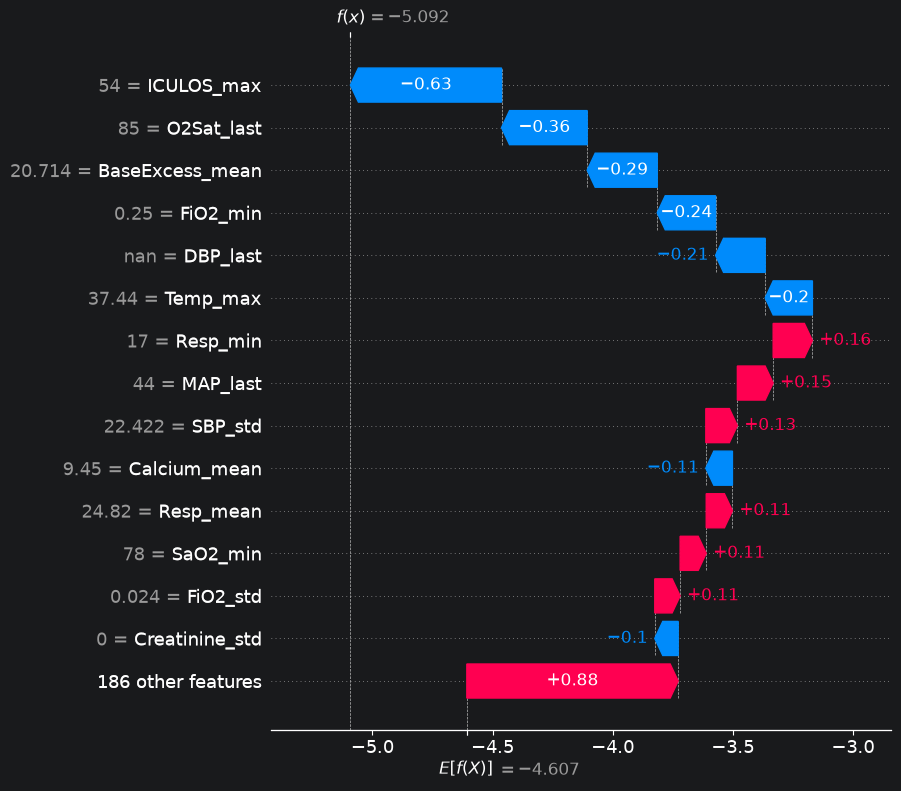

In [18]:
### waterplot for the values
shap.plots.waterfall(
    shap_explanation,
    max_display = 15
)
### the output shows what r the factors influence the patient's predicition using 15 factor

## the output is the waterfall plot

the f(x) denotes the models raw output (out put in log odd space)

blue features = pushing towards no sepsis (negative values)

red features = pushing towards sepsis (positive values)

In [19]:
# Find a high-confidence Sepsis prediction

y_prob_all = model.predict_proba(X)[:, 1]
y_pred_all = model.predict(X)

# Find samples predicted as Sepsis
sepsis_indices = np.where(y_pred_all == 1)[0]

# Select the Sepsis prediction with the highest probability
best_sepsis_index = sepsis_indices[np.argmax(y_prob_all[sepsis_indices])]

print("Selected sample index:", best_sepsis_index)
print("Model prediction:", y_pred_all[best_sepsis_index])
print("No Sepsis probability:", y_prob_all[best_sepsis_index] * 0 + (1 - y_prob_all[best_sepsis_index]))
print("Sepsis probability:", y_prob_all[best_sepsis_index])

Selected sample index: 19508
Model prediction: 1
No Sepsis probability: 0.0011007173728182496
Sepsis probability: 0.9988992826271818


In [ ]:
## sample can be entered in sample_index to identify the output of the particular patient

In [32]:
# Select the high-confidence Sepsis sample

sample_index = 19508

X_local = X.iloc[[sample_index]]

print("Selected sample shape:", X_local.shape)
print("Model prediction:", model.predict(X_local))
print("Prediction probability:", model.predict_proba(X_local))

Selected sample shape: (1, 200)
Model prediction: [1]
Prediction probability: [[0.00110072 0.99889928]]


In [33]:
### calculate local shap values
shap_local = explainer.shap_values(X_local)
## safety check
if isinstance(shap_local, list):
    shap_local_values = shap_local[1]  ### we as now want to check whether it is correct class 1 based on the output of the index
else:
    shap_local_values = shap_local

C:\Users\prajin\PycharmProjects\Explainable-Sepsis-AI\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [34]:
# Create SHAP Explanation object for the Sepsis prediction

shap_explanation_sepsis = shap.Explanation(
    values=shap_local_values[0],
    base_values=explainer.expected_value,
    data=X_local.iloc[0].values,
    feature_names=X_local.columns
)

print("Sepsis SHAP Explanation created successfully")

Sepsis SHAP Explanation created successfully


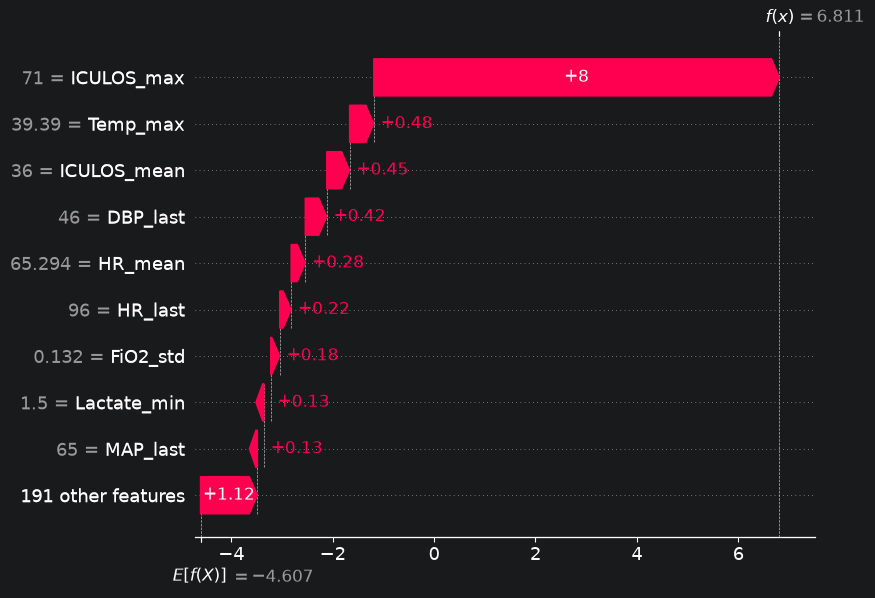

In [35]:
shap.plots.waterfall(
    shap_explanation_sepsis,
    max_display=10
)